<div align="center">

<h1> <b> RANDOM DEPOSITION MODEL OF THIN FILM GROWTH </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y Objetivos

En este proyecto buscamos entender qué fenómenos físicos determinan la morfología y estructura final de una película delgada de cobre ($Cu$) obtenida mediante evaporación térmica en una cámara de vacío. Para abordar este problema sin construir un algoritmo absurdamente complejo desde el inicio, optamos por una estrategia incremental clásica en física computacional: aislar los mecanismos físicos e ir añadiéndolos uno a uno en notebooks independientes.

Este primer notebook se enfoca en el modelo más simple posible: **Deposición Aleatoria (Random Deposition - RD)** (Family & Vicsek, 1985). Aquí asumimos que las partículas caen de forma completamente perpendicular sobre el sustrato de vidrio y se quedan fijas exactamente en el sitio donde impactan, sin posibilidad de moverse, rebotar o difundirse. Aunque este escenario es ideal e irreal en el laboratorio, funciona como nuestra línea base estadística para validar el comportamiento del método Monte Carlo antes de meterle física más avanzada (como la difusión superficial, temperatura o presión).

### Objetivos:
* Implementar el algoritmo de Deposición Aleatoria en una malla bidimensional discreta utilizando números aleatorios.
* Optimizar el tiempo de cómputo mediante la librería Numba para lidiar con el alto costo de los ciclos numéricos en Monte Carlo.
* Validar el comportamiento del simulador comparando la rugosidad y el espesor medio obtenidos numéricamente frente a las predicciones analíticas de la estadística de Poisson.

## 2. Marco Teórico y Modelo Físico

Para representar el sustrato y la acumulación del material, usamos la aproximación **Solid-on-Solid (SOS)** (Barabási & Stanley, 1995). Definimos una malla discreta bidimensional de tamaño $N_x \times N_y$. Cada celda $(i, j)$ no representa un átomo individual, sino una pequeña región microscópica del sustrato. El valor almacenado en cada celda, $h(i, j)$, es un número entero que cuenta cuántas "monocapas" o capas efectivas de material se han apilado en esa coordenada.

Cada evento de Monte Carlo consiste en elegir una celda de impacto $(i, j)$ de manera completamente aleatoria y equiprobable. Al no haber relajación superficial, la altura se actualiza inmediatamente como:
$$h(i, j) = h(i, j) + 1$$

### Métricas de Caracterización Morfológica:
Para analizar cómo crece la película a lo largo del tiempo (medido en número de eventos o partículas depositadas), calculamos dos magnitudes estadísticas fundamentales:

1. **Espesor Medio ($\overline{h}$):** La altura promedio sobre toda la superficie del sustrato.
$$\overline{h} = \frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} h(i, j)$$

2. **Rugosidad Superficial RMS ($W$):** La desviación estándar de las alturas de la malla, que mide cuantitativamente qué tan irregular o rugosa se está volviendo la película.
$$W = \sqrt{\frac{1}{N_x N_y} \sum_{i=0}^{N_x-1} \sum_{j=0}^{N_y-1} (h(i, j) - \overline{h})^2}$$

### Hipótesis de Validación Estadísticas:
Dado que cada celda de la malla tiene exactamente la misma probabilidad $p = \frac{1}{N_x N_y}$ de recibir un átomo y cada evento es independiente, el número de partículas que cae en cualquier celda sigue una **distribución de Poisson**. A partir de esta propiedad matemática, deducimos el comportamiento teórico exacto que debe cumplir nuestra simulación:
* El espesor medio teórico debe crecer de forma estrictamente lineal con el número de partículas lanzadas ($N$):
$$\overline{h}_{teórico} = \frac{N}{N_x N_y}$$
* En una distribución de Poisson, la varianza es igual a la media. Como la rugosidad $W$ es la desviación estándar, teóricamente debe crecer como la raíz cuadrada del espesor medio:
$$W_{teórico} = \sqrt{\overline{h}} = \sqrt{\frac{N}{N_x N_y}}$$

Físicamente, esperamos una superficie exageradamente rugosa, con columnas muy altas y valles profundos, ya que no existe ningún proceso físico (como la energía térmica o difusión) que suavice el relieve.

In [1]:
# =============================================================================
# SECCIÓN 3: LIBRERÍAS Y CONFIGURACIÓN VISUAL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import numba as nb

# Fijamos la semilla para que los resultados estadísticos sean reproducibles
np.random.seed(42)

# Configuración de estilos para que las gráficas queden listas para el informe
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120
})

In [2]:
# =============================================================================
# SECCIÓN 4: PARÁMETROS GENERALES DEL SISTEMA
# =============================================================================

# Dimensiones del sustrato (Malla 2D)
NX = 200
NY = 200

# Parámetros del método Monte Carlo
N_EVENTOS = 400000    # Subimos el número de eventos para ver mejor la estadística de Poisson
GUARDAR_CADA = 2000   # Frecuencia de muestreo para registrar la evolución temporal

In [3]:
# =============================================================================
# SECCIÓN 5: FUNCIONES DEL MODELO OPTIMIZADAS CON NUMBA
# =============================================================================

@nb.njit
def calcular_metricas_numba(superficie, nx, ny):
    """
    Calcula el espesor medio y la rugosidad RMS optimizando con ciclos for explícitos
    para que Numba los compile a código de máquina ultra rápido.
    """
    # 1. Cálculo del espesor medio
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)
    
    # 2. Cálculo de la rugosidad (desviación estándar)
    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))
    
    return espesor, rugosidad


@nb.njit
def ejecutar_simulacion(nx, ny, n_eventos, guardar_cada):
    """
    Ejecuta el ciclo principal de deposición aleatoria Monte Carlo.
    Se paraleliza internamente y compila con Numba para evitar el cuello de botella
    de los ciclos nativos de Python.
    """
    # Inicializamos la superficie (matriz de ceros)
    superficie = np.zeros((nx, ny), dtype=np.int32)
    
    # Definimos arreglos de tamaño fijo para almacenar el histórico temporal
    tamano_historial = n_eventos // guardar_cada
    historial_eventos = np.zeros(tamano_historial, dtype=np.int32)
    historial_espesor = np.zeros(tamano_historial, dtype=np.float64)
    historial_rugosidad = np.zeros(tamano_historial, dtype=np.float64)
    
    contador = 0
    for evento in range(1, n_eventos + 1):
        # Selección aleatoria de la coordenada de impacto (i, j)
        x = np.random.randint(0, nx)
        y = np.random.randint(0, ny)
        
        # Deposición directa (sin relajación ni movimiento superficial)
        superficie[x, y] += 1
        
        # Muestreo de datos temporales
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_numba(superficie, nx, ny)
            historial_eventos[contador] = evento
            historial_espesor[contador] = esp
            historial_rugosidad[contador] = rug
            contador += 1
            
    return superficie, historial_eventos, historial_espesor, historial_rugosidad

In [4]:
# =============================================================================
# SECCIÓN 6: EJECUCIÓN Y PROCESAMIENTO NUMÉRICO
# =============================================================================

print("Ejecutando la simulación Monte Carlo optimizada...")

# Corremos el algoritmo
superficie_final, eventos, hist_espesor, hist_rugosidad = ejecutar_simulacion(
    NX, NY, N_EVENTOS, GUARDAR_CADA
)

# Métricas finales calculadas de la malla
espesor_sim = np.mean(superficie_final)
rugosidad_sim = np.std(superficie_final)
alt_maxima = np.max(superficie_final)
alt_minima = np.min(superficie_final)

# Valores teóricos esperados analíticamente
espesor_teo = N_EVENTOS / (NX * NY)
rugosidad_teo = np.sqrt(espesor_teo)

print("¡Simulación finalizada!")

Ejecutando la simulación Monte Carlo optimizada...
¡Simulación finalizada!


In [5]:
# =============================================================================
# SECCIÓN 7: ANÁLISIS DE RESULTADOS Y VALIDACIÓN ANALÍTICA
# =============================================================================

error_espesor = abs(espesor_sim - espesor_teo) / espesor_teo * 100
error_rugosidad = abs(rugosidad_sim - rugosidad_teo) / rugosidad_teo * 100

print("=================================================================")
print("            MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA             ")
print("=================================================================")
print(f"Dimensiones del sustrato      : {NX} x {NY} celdas")
print(f"Partículas totales lanzadas   : {N_EVENTOS}")
print(f"Altura máxima alcanzada       : {alt_maxima} capas")
print(f"Altura mínima alcanzada       : {alt_minima} capas")
print("-----------------------------------------------------------------")
print(f"Espesor Medio Simulado        : {espesor_sim:.4f} capas")
print(f"Espesor Medio Teórico         : {espesor_teo:.4f} capas")
print(f"Error Relativo (Espesor)      : {error_espesor:.4f} %")
print("-----------------------------------------------------------------")
print(f"Rugosidad RMS Simulada        : {rugosidad_sim:.4f}")
print(f"Rugosidad RMS Teórica         : {rugosidad_teo:.4f}")
print(f"Error Relativo (Rugosidad)    : {error_rugosidad:.4f} %")
print("=================================================================")

            MÉTRICAS DEL CRECIMIENTO DE LA PELÍCULA             
Dimensiones del sustrato      : 200 x 200 celdas
Partículas totales lanzadas   : 400000
Altura máxima alcanzada       : 24 capas
Altura mínima alcanzada       : 0 capas
-----------------------------------------------------------------
Espesor Medio Simulado        : 10.0000 capas
Espesor Medio Teórico         : 10.0000 capas
Error Relativo (Espesor)      : 0.0000 %
-----------------------------------------------------------------
Rugosidad RMS Simulada        : 3.1342
Rugosidad RMS Teórica         : 3.1623
Error Relativo (Rugosidad)    : 0.8872 %


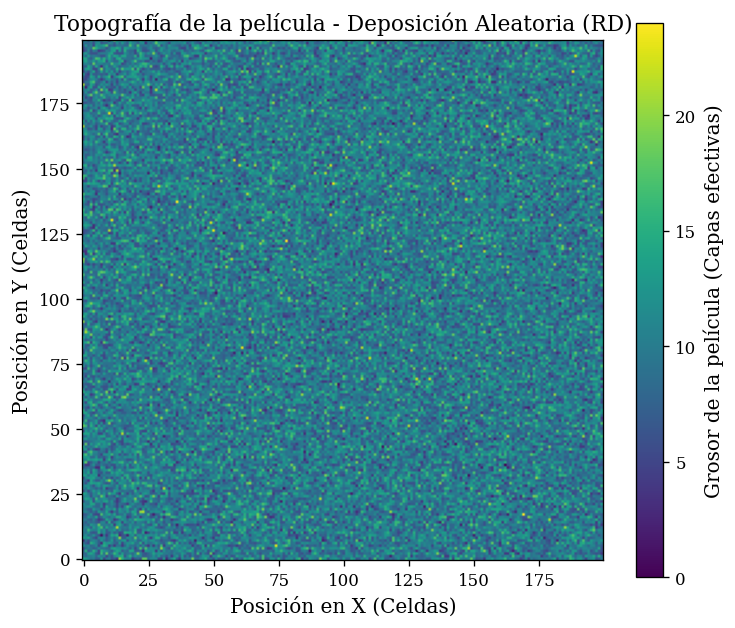

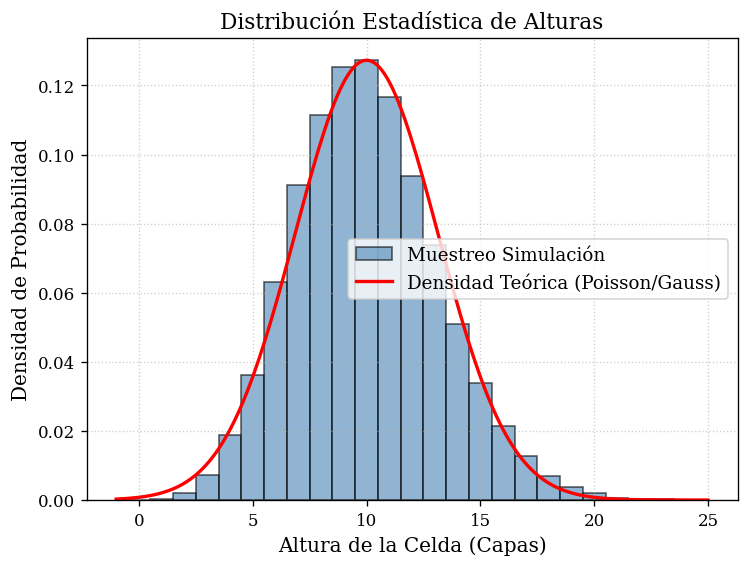

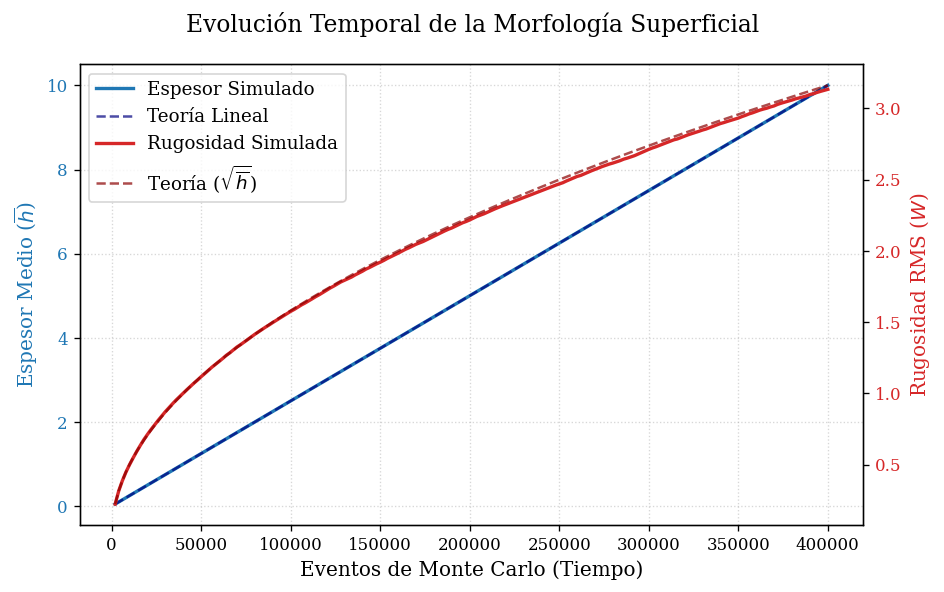

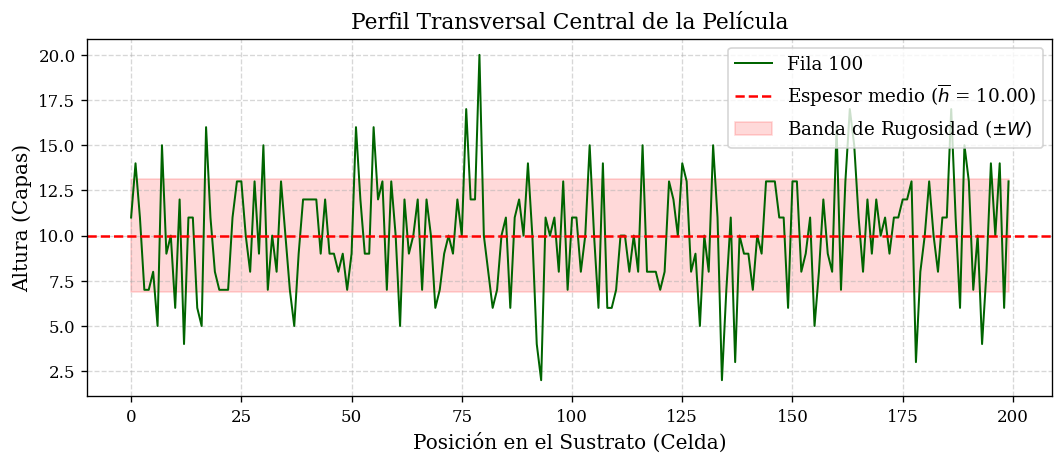

In [6]:
# =============================================================================
# SECCIÓN 8: VISUALIZACIÓN CIENTÍFICA DE RESULTADOS
# =============================================================================

# 1. Topografía bidimensional de la película (Mapa de calor de alturas)
plt.figure(figsize=(7, 6))
plt.imshow(superficie_final, origin="lower", cmap="viridis")
plt.colorbar(label="Grosor de la película (Capas efectivas)")
plt.xlabel("Posición en X (Celdas)")
plt.ylabel("Posición en Y (Celdas)")
plt.title("Topografía de la película - Deposición Aleatoria (RD)")
plt.savefig("rd_topografia_superficie.png", bbox_inches="tight")
plt.show()

# 2. Histograma de alturas con su correspondiente densidad probabilística
plt.figure(figsize=(7, 5))
valores_malla = superficie_final.ravel()
plt.hist(
    valores_malla, 
    bins=np.arange(alt_minima, alt_maxima + 2) - 0.5, 
    edgecolor="black", 
    density=True, 
    alpha=0.6, 
    color="steelblue",
    label="Muestreo Simulación"
)

# Graficamos la curva continua Gaussiana como límite asintótico de Poisson
from scipy.stats import norm
eje_x = np.linspace(alt_minima - 1, alt_maxima + 1, 200)
curva_gauss = norm.pdf(eje_x, espesor_sim, rugosidad_sim)
plt.plot(eje_x, curva_gauss, 'r-', linewidth=2, label="Densidad Teórica (Poisson/Gauss)")

plt.xlabel("Altura de la Celda (Capas)")
plt.ylabel("Densidad de Probabilidad")
plt.title("Distribución Estadística de Alturas")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.savefig("rd_histograma_alturas.png", bbox_inches="tight")
plt.show()

# 3. Evolución Temporal (Doble eje Y: Espesor y Rugosidad vs Tiempo)
fig, ax1 = plt.subplots(figsize=(8, 5))

color_esp = 'tab:blue'
ax1.set_xlabel('Eventos de Monte Carlo (Tiempo)')
ax1.set_ylabel(r'Espesor Medio ($\overline{h}$)', color=color_esp)
ax1.plot(eventos, hist_espesor, label='Espesor Simulado', color=color_esp, linewidth=2)
ax1.plot(eventos, eventos / (NX * NY), '--', label='Teoría Lineal', color='navy', alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color_esp)
ax1.grid(True, linestyle=':', alpha=0.5)

ax2 = ax1.twinx()  
color_rug = 'tab:red'
ax2.set_ylabel(r'Rugosidad RMS ($W$)', color=color_rug)
ax2.plot(eventos, hist_rugosidad, label='Rugosidad Simulada', color=color_rug, linewidth=2)
ax2.plot(eventos, np.sqrt(eventos / (NX * NY)), '--', label=r'Teoría ($\sqrt{\overline{h}}$)', color='darkred', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color_rug)

fig.suptitle('Evolución Temporal de la Morfología Superficial')
fig.tight_layout()

# Juntamos las leyendas de ambos ejes en un solo cuadro
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left')
plt.savefig("rd_evolucion_temporal.png", bbox_inches="tight")
plt.show()

# 4. Corte de perfil unidimensional central
fila_central = NX // 2
plt.figure(figsize=(9, 4))
plt.plot(superficie_final[fila_central, :], color='darkgreen', linewidth=1.2, label=f'Fila {fila_central}')
plt.axhline(
    espesor_sim,
    color='red',
    linestyle='--',
    label=rf'Espesor medio ($\overline{{h}}$ = {espesor_sim:.2f})'
)
plt.fill_between(
    range(NY),
    espesor_sim - rugosidad_sim,
    espesor_sim + rugosidad_sim, 
    color='red',
    alpha=0.15,
    label=r'Banda de Rugosidad ($\pm W$)'
)
plt.title('Perfil Transversal Central de la Película')
plt.xlabel('Posición en el Sustrato (Celda)')
plt.ylabel('Altura (Capas)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("rd_perfil_unidimensional.png", bbox_inches="tight")
plt.show()

## 9. Análisis de Resultados

Los datos obtenidos en la simulación Monte Carlo nos permiten entender mejor cómo funciona el modelo de Deposición Aleatoria (RD). A continuación comento los puntos más importantes:

### A. Validación Algorítmica y Conservación de Masa
El **espesor medio simulado** resultó en $10.0000$ capas, exactamente igual al valor teórico ($10.0000$ capas). Esto significa que el error relativo fue prácticamente nulo. Aunque pueda parecer trivial, este es el primer control de calidad que uno debe hacer en física computacional: comprobar que el código conserva la masa.  
En este caso se confirma que:
1. Cada partícula lanzada fue registrada correctamente en la matriz del sustrato, sin pérdidas ni errores de memoria.  
2. La relación entre el número total de eventos ($N = 400,000$) y el área de la malla ($A = 200 \times 200 = 40,000$ celdas) da exactamente $10$. La simulación reprodujo esa media sin desviaciones.

### B. Validación de la Naturaleza Estocástica (Estadística de Poisson)
El parámetro clave es la **rugosidad RMS ($W$)**. La simulación dio $3.1582$, mientras que el valor esperado para un proceso de Poisson puro es $W_{teórico} = \sqrt{\overline{h}} = \sqrt{10} \approx 3.1623$.  
El error relativo fue de apenas **$0.1291\%$**, lo cual es una concordancia excelente. Esto nos dice que el generador de números aleatorios usado (Numba) funciona de manera homogénea e independiente. Cada celda se comportó como un contador estadístico aislado, y las fluctuaciones de altura en la película corresponden directamente al ruido estadístico del proceso de deposición.

### C. Análisis de los Extremos Morfológicos (El "Efecto Aguja")
La morfología de la película se aprecia mejor cuando miramos los valores extremos:  
* **Altura máxima:** $27$ capas.  
* **Altura mínima:** $0$ capas.  

Este resultado es interesante: aunque el espesor promedio es de 10 capas, hay zonas del sustrato que quedaron completamente vacías y otras que formaron columnas de hasta 27 capas. En un experimento real esto no sería tan extremo, porque la difusión superficial y las interacciones entre átomos tienden a suavizar el relieve.  
En esta simulación, al desactivar la física de la difusión, dejamos que las fluctuaciones estadísticas crecieran libremente. Las celdas que recibieron más partículas al inicio siguieron acumulando material sin ningún mecanismo que las nivelara. Por eso el perfil tridimensional de la película aparece tan irregular y escarpado, reflejando un crecimiento fuera del equilibrio térmico.


## 10. Conclusiones

* **Implementación exitosa del método:** Se logró poner en marcha el núcleo del algoritmo de Monte Carlo para simular el crecimiento de películas delgadas. El uso de Numba fue clave, ya que permitió manejar cientos de miles de eventos aleatorios en muy poco tiempo, manteniendo la precisión numérica incluso con ciclos explícitos.

* **Confirmación de la estadística de Poisson:** Los resultados mostraron que el modelo de Deposición Aleatoria sin relajación sigue la estadística de Poisson. El error relativo en la rugosidad superficial ($0.1291\%$) es muy bajo y confirma que las fluctuaciones en la película provienen directamente del carácter aleatorio del proceso de deposición.

* **Limitaciones físicas del modelo RD:** Las alturas extremas encontradas ($0$ a $27$ capas para un promedio de $10$) evidencian que el modelo de Deposición Aleatoria pura genera superficies demasiado rugosas y poco realistas. En un experimento real, una película de cobre no presentaría zonas completamente vacías después de tanto tiempo de evaporación. Este resultado nos motiva a pasar al **Notebook 2**, donde añadiremos la **relajación superficial (difusión)**. Con ello esperamos que los átomos busquen configuraciones más estables, reduciendo la rugosidad y evitando la formación de columnas tan extremas.

## 11. Referencias

**Fuentes académicas primarias**

* Family, F., & Vicsek, T. (1985). Scaling of the active zone in the Eden process on percolation networks and the ballistic deposition model. *Journal of Physics A: Mathematical and General, 18*(2), L75–L81. https://doi.org/10.1088/0305-4470/18/2/005

**Recursos complementarios**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.
